In [1]:


# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [2]:
df = pd.read_csv("data/heart_disease_risk_2026.csv")



In [3]:
# Dataset Overview
# ==========================================

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

display(df.sample(5))

Rows    : 9000
Columns : 27


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
3230,3231,61,Male,123,80,199,61,118,159,109,...,True,Never,2.7,219,8.3,19.6,True,6102,81.3,0
1041,1042,65,Female,135,77,212,69,97,186,129,...,False,Current,3.5,176,7.3,48.7,True,7392,34.4,0
8664,8665,54,Male,143,90,166,52,103,35,121,...,False,Current,10.1,187,6.9,52.5,False,7160,83.9,0
5342,5343,68,Male,138,97,214,66,134,81,82,...,False,Former,2.0,152,5.3,54.0,True,6866,68.5,1
431,432,64,Female,140,85,278,53,175,228,167,...,False,Never,3.1,5,7.4,48.7,False,591,33.5,0


In [4]:
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [5]:
# Data Quality Report
# ==========================================

quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2),
    "Unique Values": df.nunique()
})

display(quality)

print(f"Duplicate Rows : {df.duplicated().sum()}")

,Data Type,Missing,Missing %,Unique Values
patient_id,int64,0,0.0,9000
age,int64,0,0.0,73
sex,object,0,0.0,2
resting_bp_systolic,int64,0,0.0,93
resting_bp_diastolic,int64,0,0.0,71
cholesterol_total,int64,0,0.0,200
hdl,int64,0,0.0,81
ldl,int64,0,0.0,163
triglycerides,int64,0,0.0,281
fasting_blood_sugar,int64,0,0.0,136


Duplicate Rows : 0


In [6]:
# Statistical Summary
# ==========================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
patient_id,9000.0,4500.500000,2598.220545,1.0,2250.75,4500.5,6750.25,9000.0
age,9000.0,53.977333,13.008051,18.0,45.00,54.0,63.00,90.0
resting_bp_systolic,9000.0,127.849778,13.767233,85.0,119.00,128.0,137.00,181.0
resting_bp_diastolic,9000.0,80.788778,10.939943,50.0,74.00,81.0,88.00,126.0
cholesterol_total,9000.0,188.753556,32.271644,90.0,167.00,189.0,211.00,314.0
hdl,9000.0,55.215333,12.394400,18.0,47.00,55.0,64.00,110.0
ldl,9000.0,103.275556,27.342198,35.0,85.00,103.0,122.00,207.0
triglycerides,9000.0,152.045000,51.448384,35.0,117.00,151.0,186.00,390.0
fasting_blood_sugar,9000.0,119.470444,22.778082,60.0,104.00,119.0,135.00,204.0
hba1c,9000.0,5.791633,0.692645,4.0,5.30,5.8,6.30,8.6


In [7]:
# Feature Types
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()

cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features :", len(num_cols))
print("Categorical Features :", len(cat_cols))

Numerical Features : 21
Categorical Features : 6


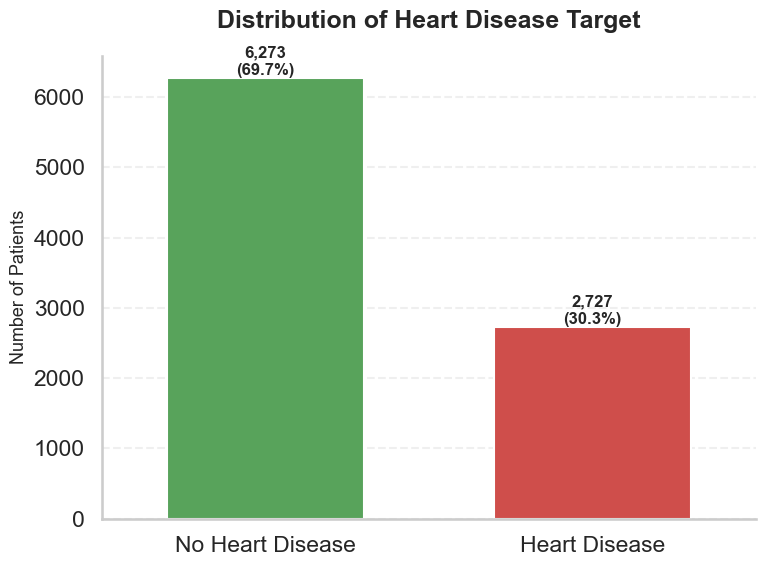

In [8]:


# Style
sns.set_theme(style="whitegrid", context="talk")

# Figure
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="has_heart_disease",
    palette=["#4CAF50", "#E53935"],
    width=0.6
)

# Rename classes
ax.set_xticklabels(["No Heart Disease", "Heart Disease"])

# Total samples
total = len(df)

# Labels 
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f'{count:,}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Titles
plt.title(
    "Distribution of Heart Disease Target",
    fontsize=18,
    weight='bold',
    pad=20
)

plt.xlabel("")
plt.ylabel("Number of Patients", fontsize=13)

# Remove top/right borders
sns.despine()

# Light grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

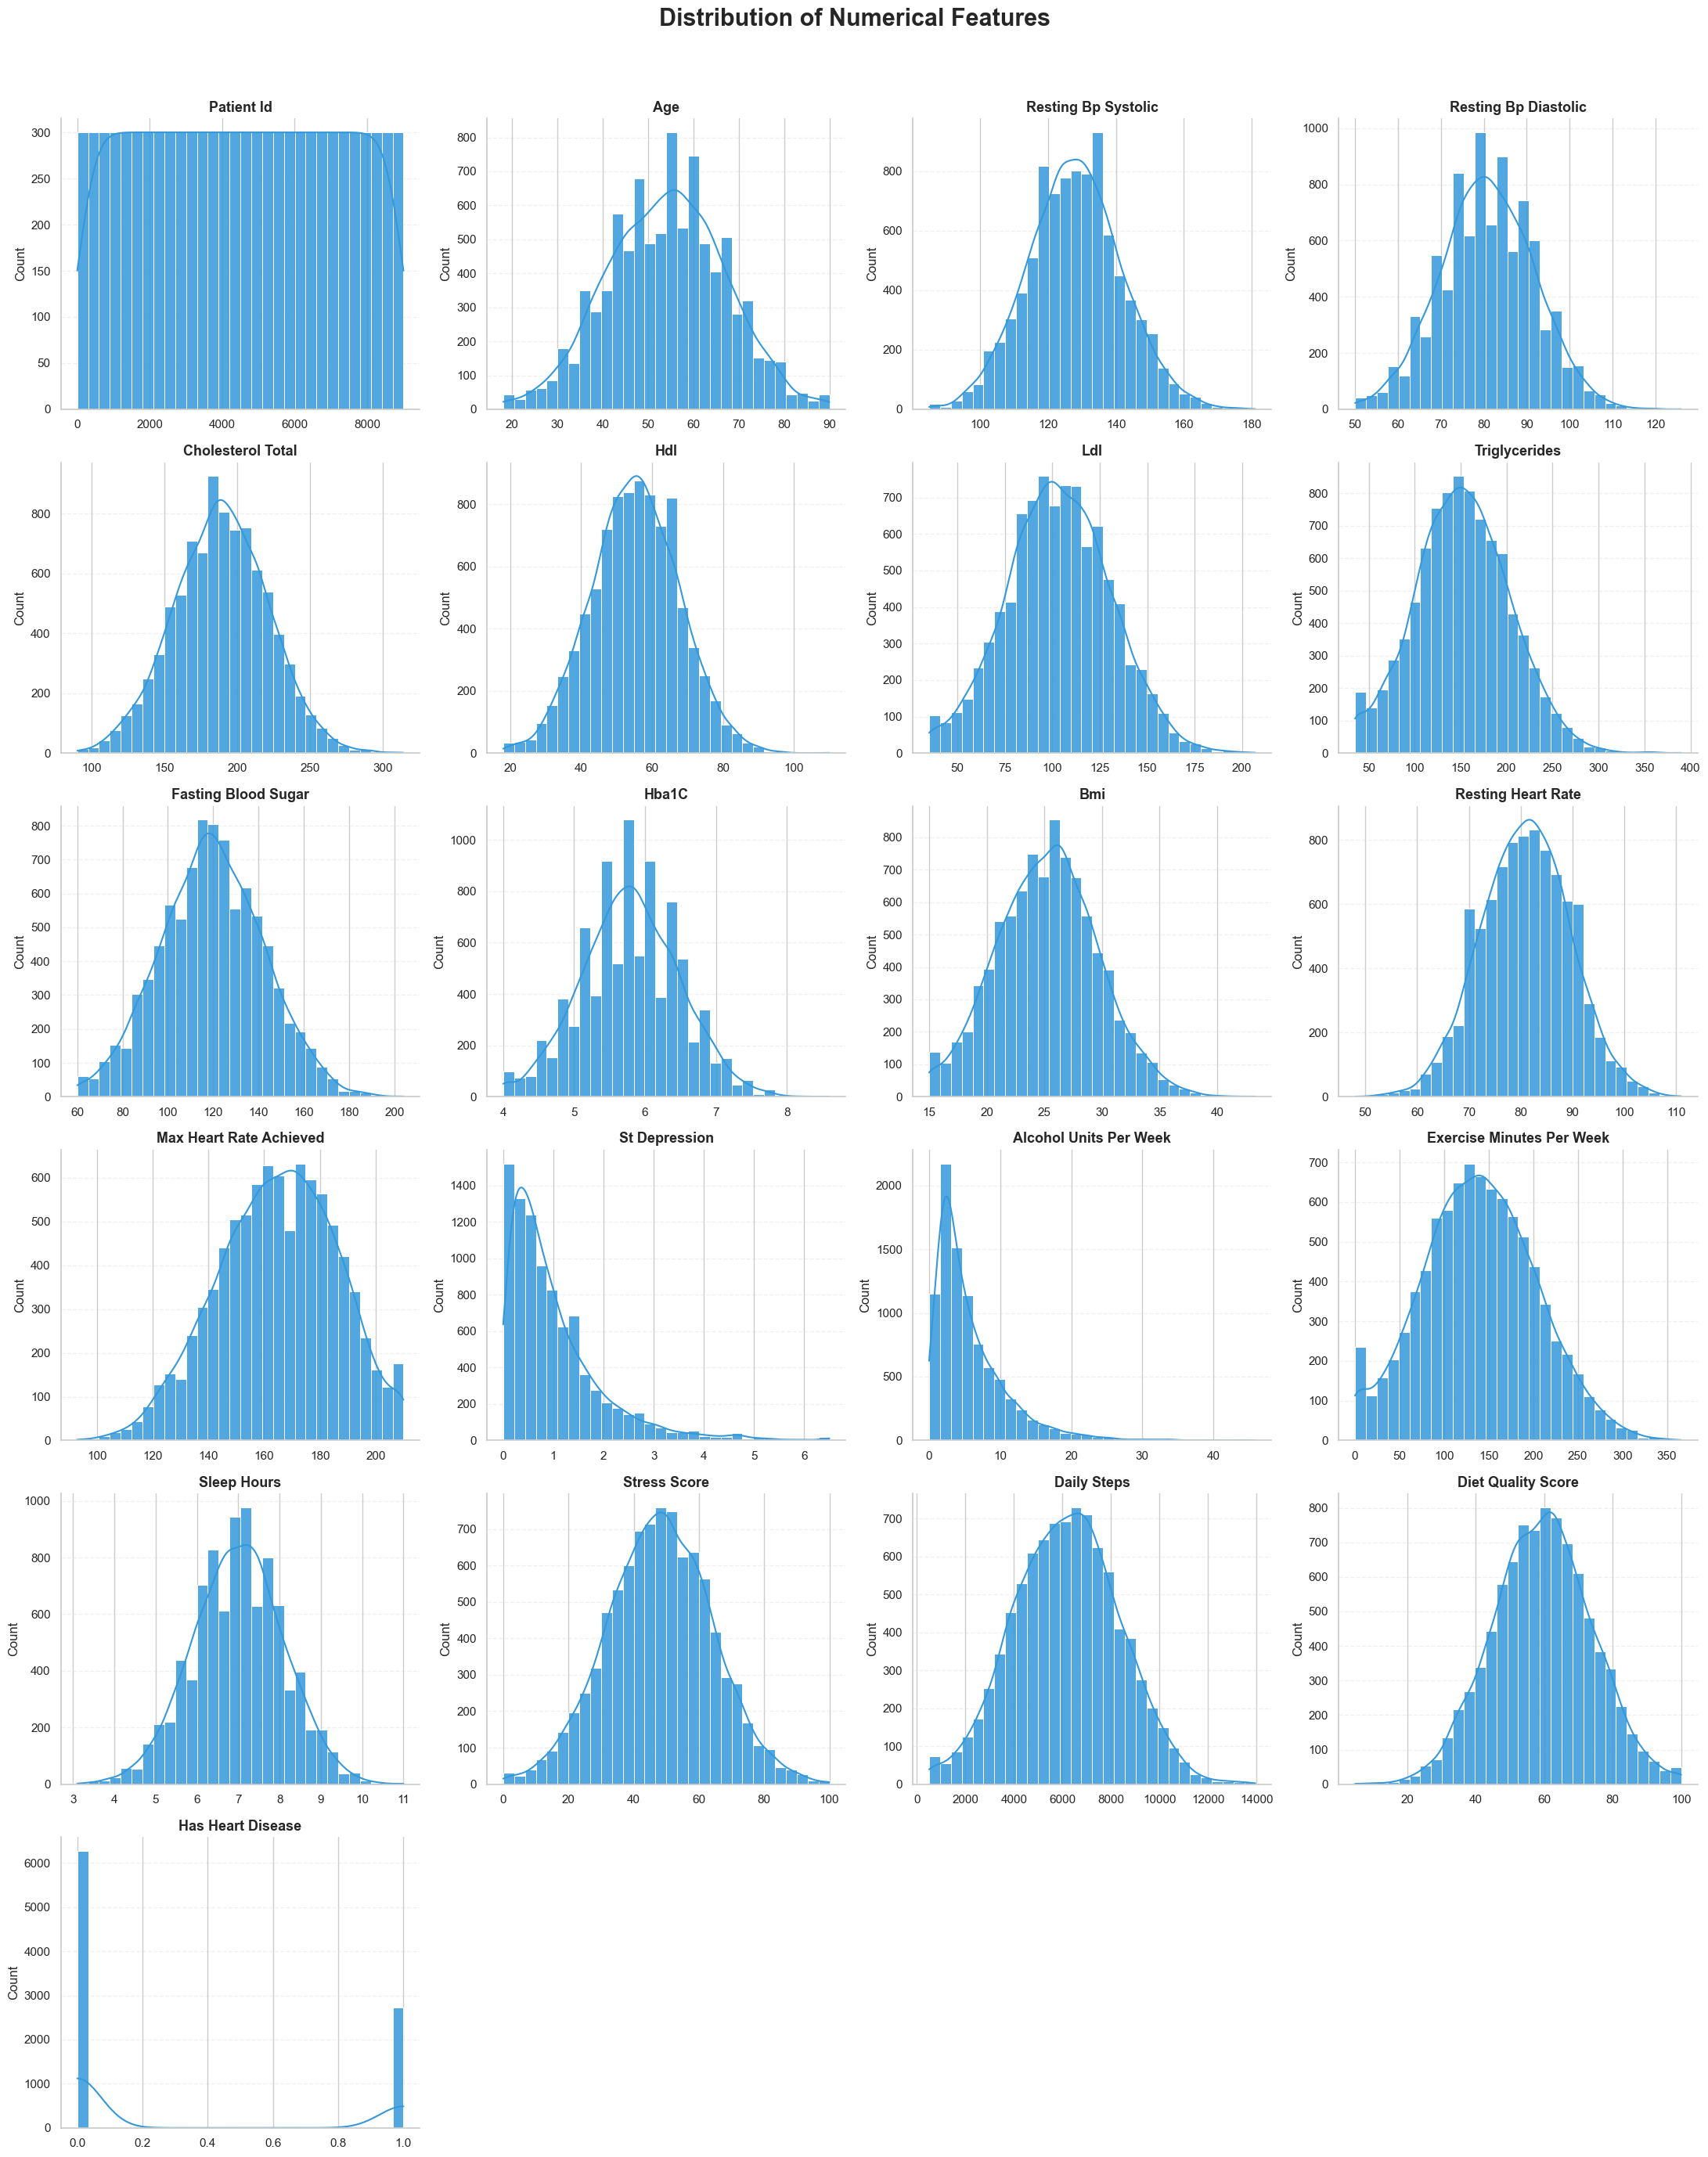

In [9]:


# Style
sns.set_theme(style="whitegrid", context="notebook")

cols = 4


rows = math.ceil(len(num_cols) / cols)

# Figure
fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4.5))
axes = axes.flatten()

# رسم كل Feature
for i, col in enumerate(num_cols):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="#3498DB",
        edgecolor="white",
        linewidth=0.7,
        alpha=0.85,
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    axes[i].grid(axis="y", linestyle="--", alpha=0.3)
    sns.despine(ax=axes[i])

# حذف الرسومات الفاضية
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

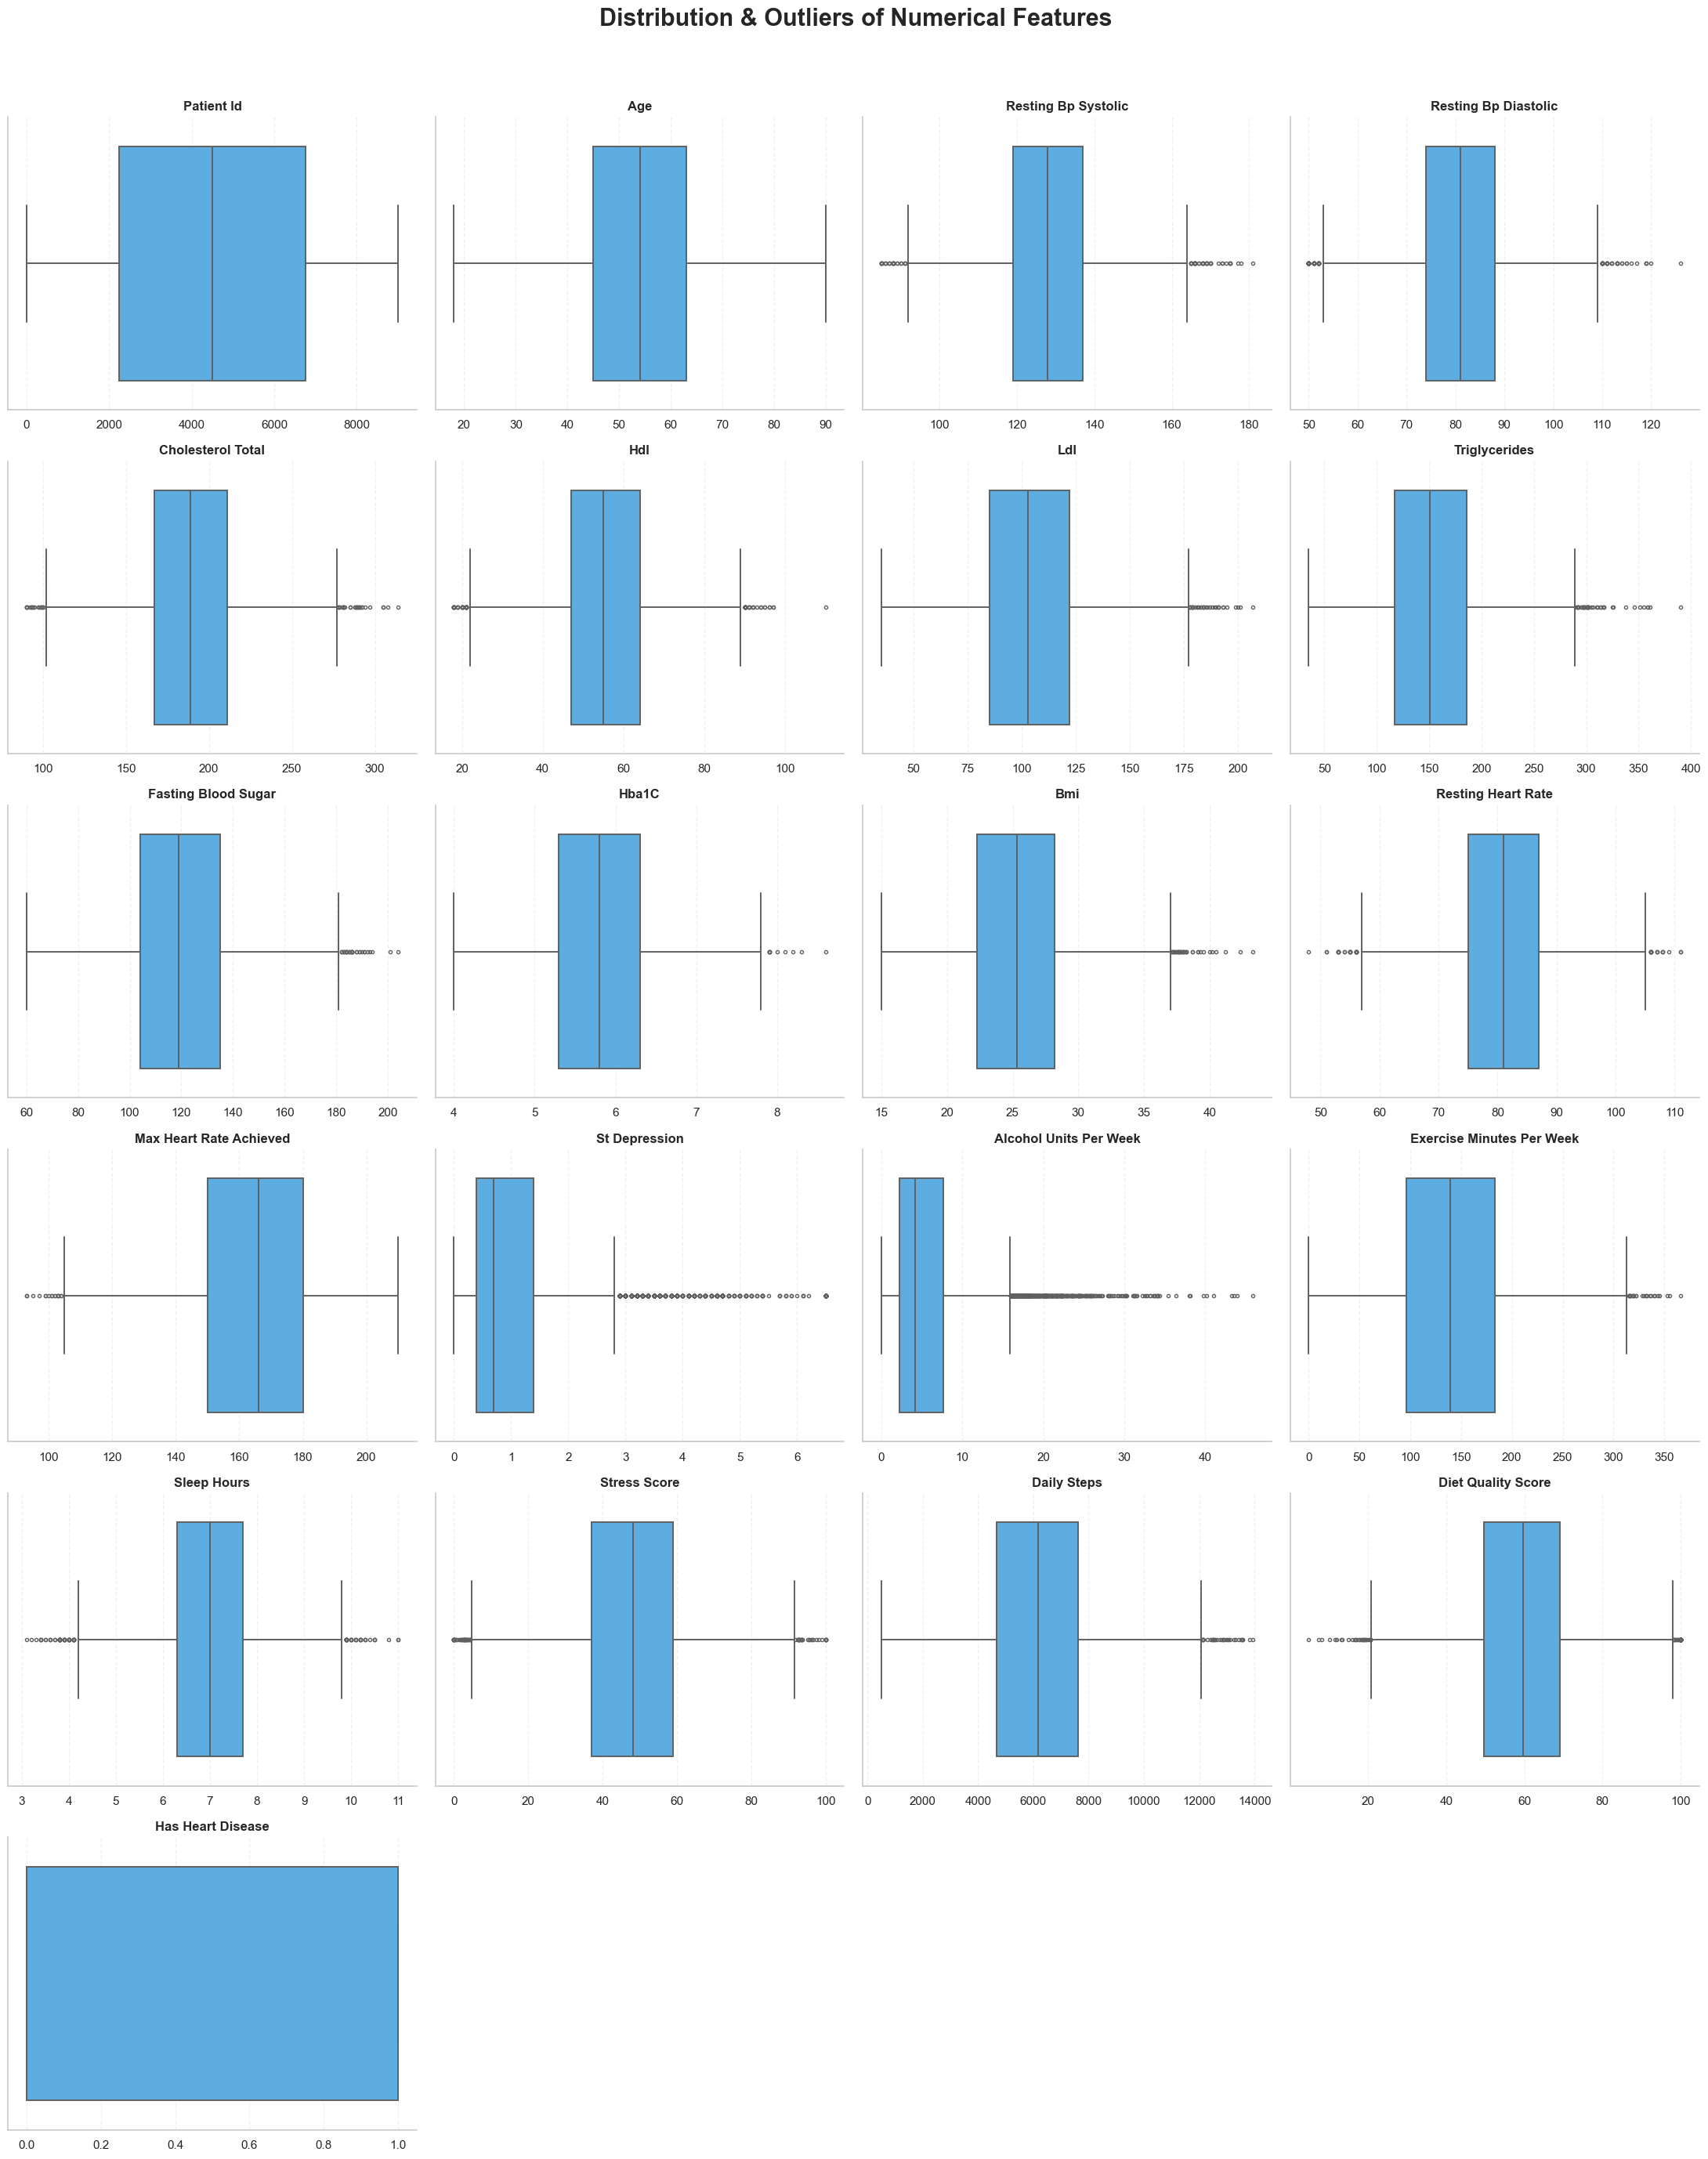

In [10]:

# Syle
sns.set_theme(style="whitegrid", context="notebook")

n_cols = 4

n_rows = math.ceil(len(num_cols) / n_cols)

# Figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 4.5 * n_rows)
)

axes = axes.flatten()

#Boxplots
for i, col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color="#5DADE2",
        linewidth=1.4,
        fliersize=3,
        saturation=1
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    axes[i].grid(axis="x", linestyle="--", alpha=0.3)

    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution & Outliers of Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

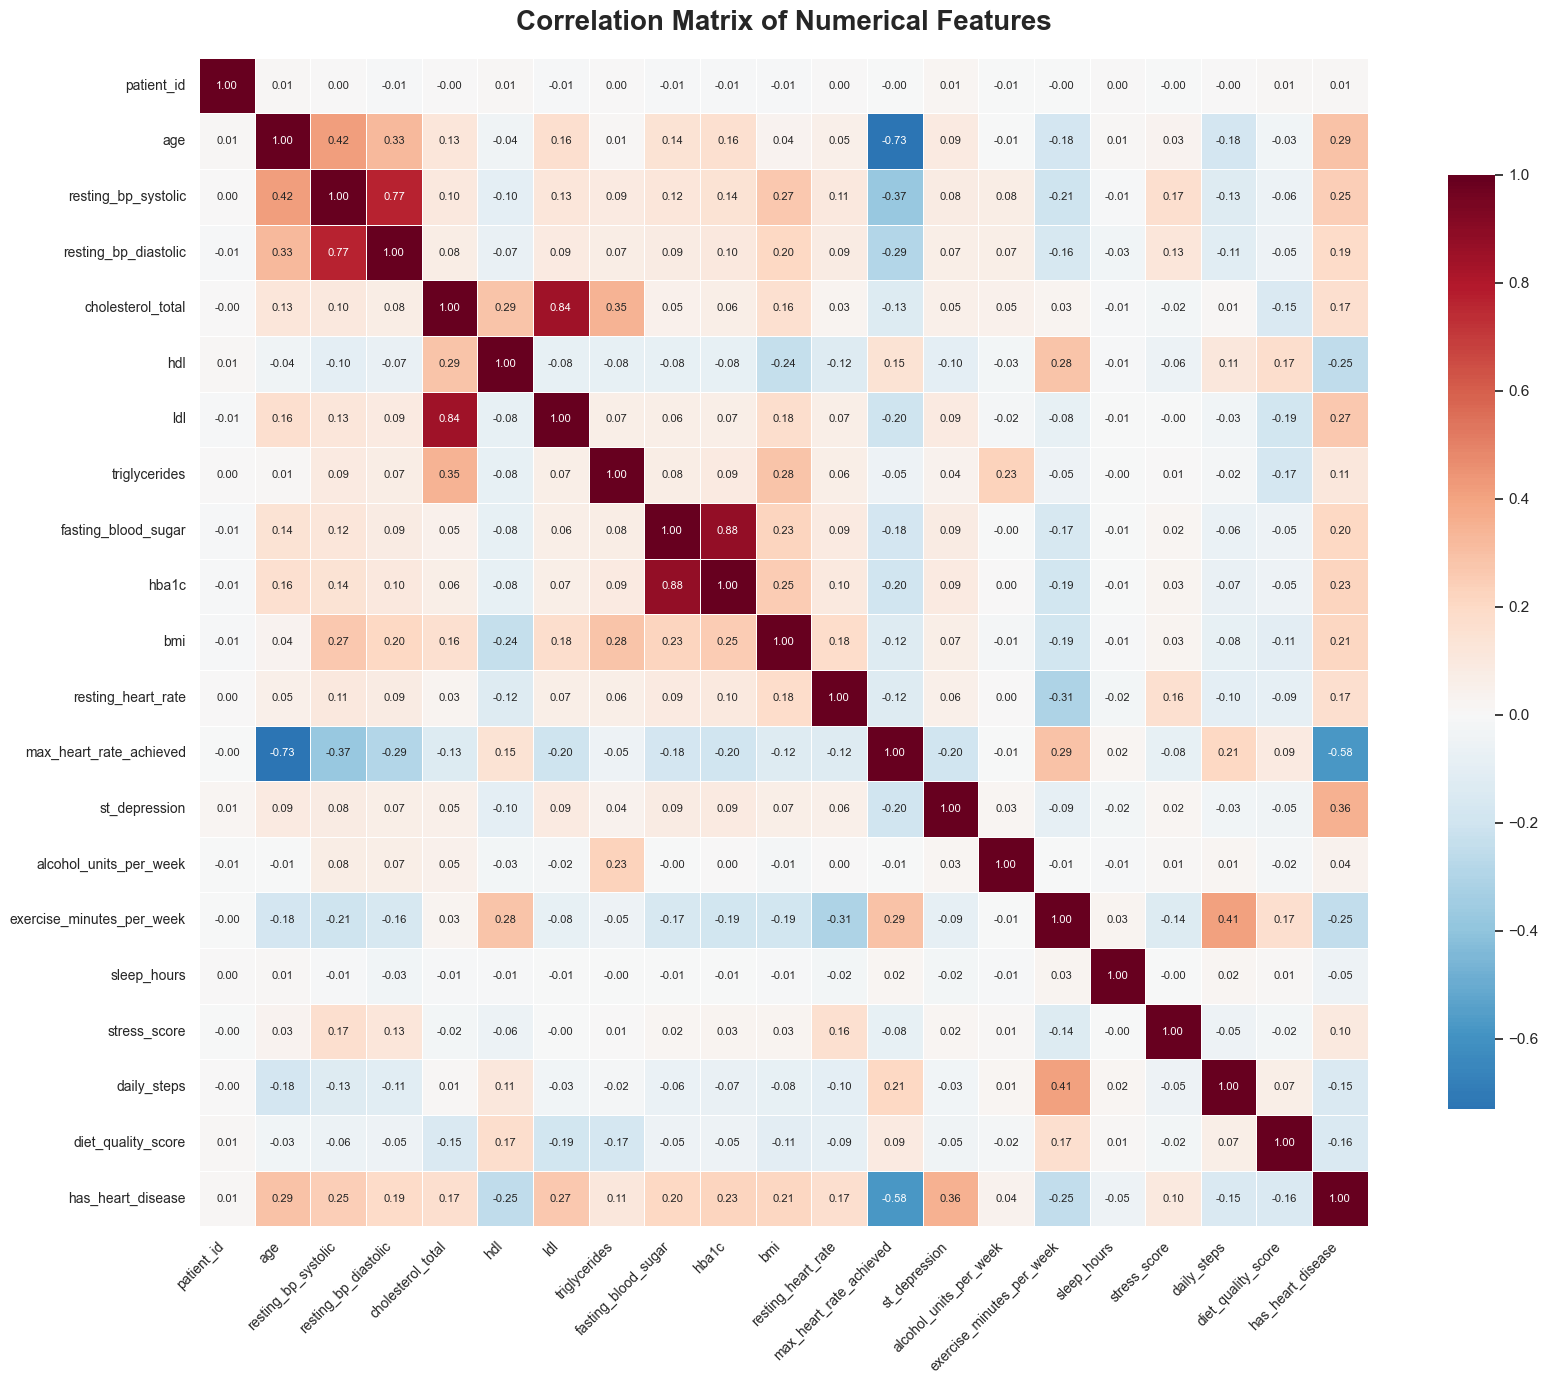

In [11]:

# Style
sns.set_theme(style="white")

# Correlation
corr = df[num_cols].corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size":8},
    cbar_kws={"shrink":0.8}
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

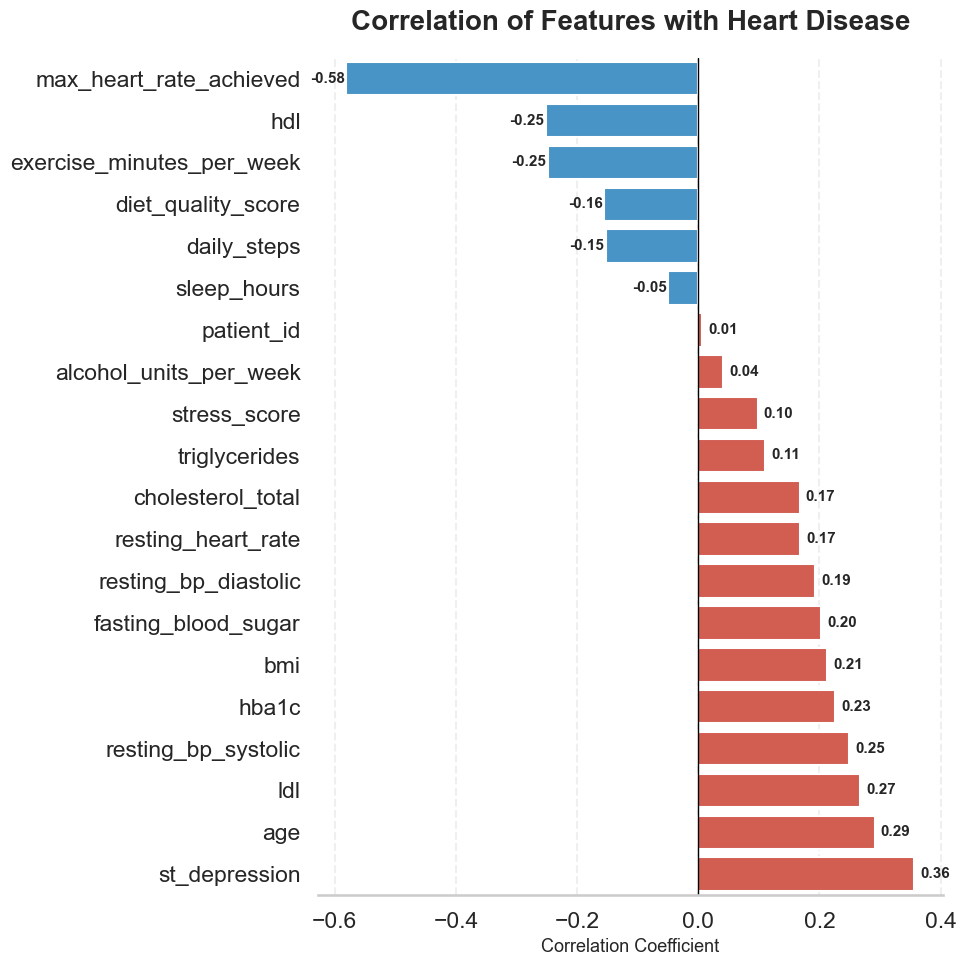

In [12]:

# Style
sns.set_theme(style="whitegrid", context="talk")

# Correlation with target
corr_target = (
    df[num_cols]
    .corr()["has_heart_disease"]
    .drop("has_heart_disease")
    .sort_values()
)

# Color
colors = [
    "#E74C3C" if x > 0 else "#3498DB"
    for x in corr_target.values
]

plt.figure(figsize=(10,10))

ax = sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette=colors
)

# Correlation
for i, v in enumerate(corr_target.values):
    ax.text(
        v + (0.01 if v >= 0 else -0.06),
        i,
        f"{v:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Correlation of Features with Heart Disease",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Correlation Coefficient", fontsize=13)
plt.ylabel("")

sns.despine(left=True)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


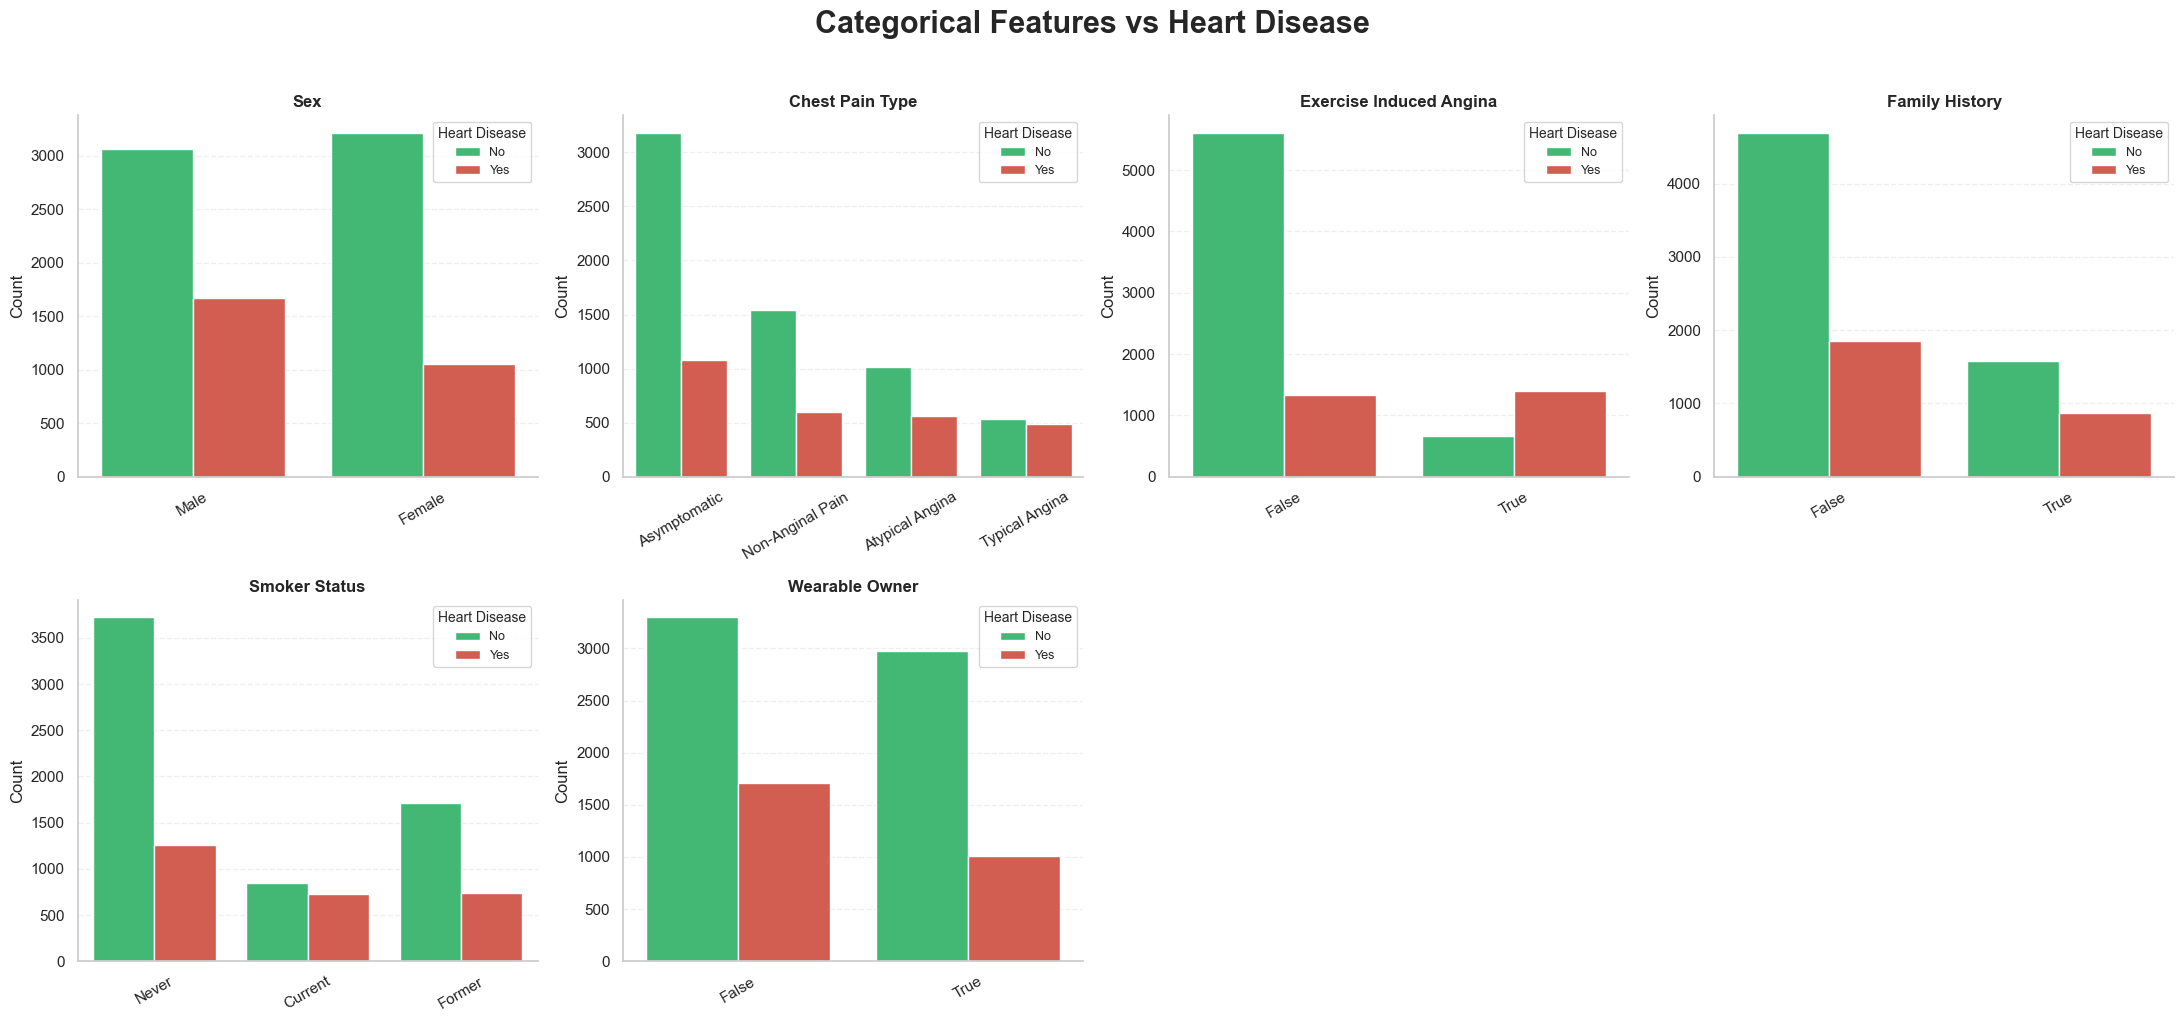

In [13]:


# Style
sns.set_theme(style="whitegrid", context="notebook")

n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df,
        x=col,
        hue="has_heart_disease",
        palette=["#2ECC71", "#E74C3C"],
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    axes[i].tick_params(axis="x", rotation=30)

    axes[i].legend(
        title="Heart Disease",
        labels=["No", "Yes"],
        fontsize=9,
        title_fontsize=10
    )

    axes[i].grid(axis="y", linestyle="--", alpha=0.3)

    sns.despine(ax=axes[i])

# حذف الرسومات الفاضية
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Categorical Features vs Heart Disease",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

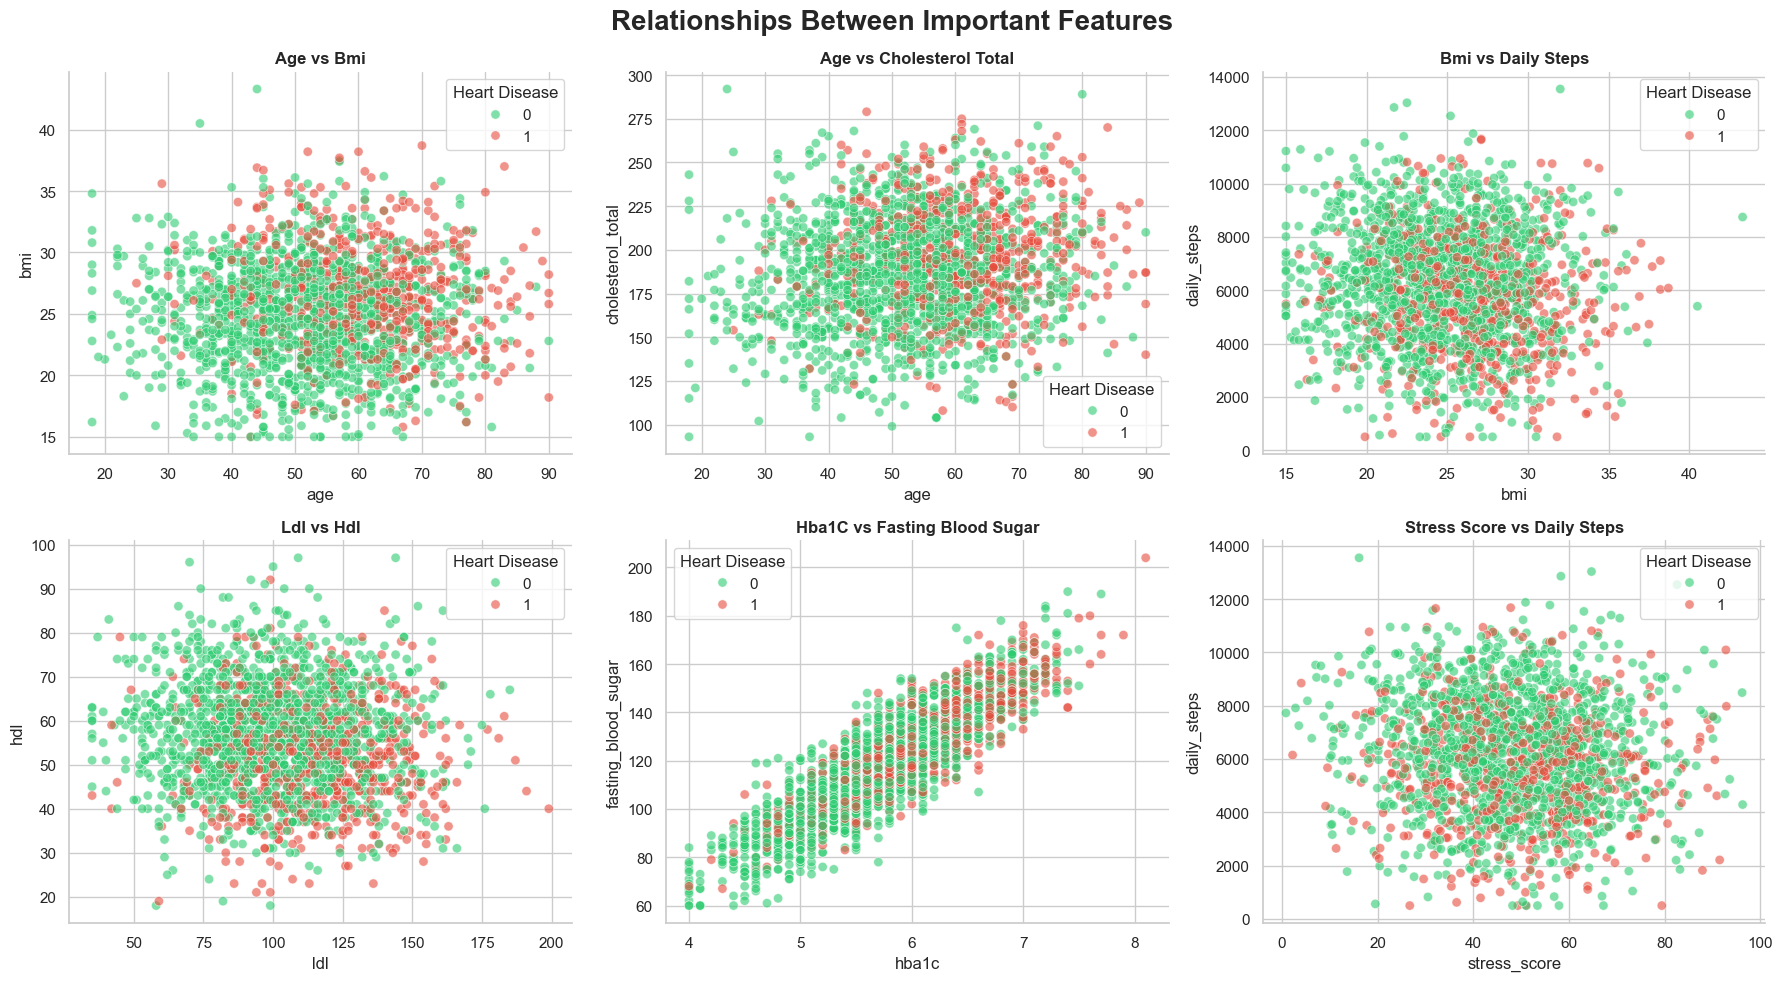

In [14]:

sns.set_theme(style="whitegrid", context="notebook")

feature_pairs = [
    ("age", "bmi"),
    ("age", "cholesterol_total"),
    ("bmi", "daily_steps"),
    ("ldl", "hdl"),
    ("hba1c", "fasting_blood_sugar"),
    ("stress_score", "daily_steps")
]

n_cols = 3
n_rows = math.ceil(len(feature_pairs) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, (x, y) in enumerate(feature_pairs):

    sns.scatterplot(
        data=df.sample(min(2000, len(df)), random_state=42),
        x=x,
        y=y,
        hue="has_heart_disease",
        palette=["#2ECC71", "#E74C3C"],
        alpha=0.6,
        s=45,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{x.replace('_',' ').title()} vs {y.replace('_',' ').title()}",
        fontweight="bold"
    )

    axes[i].legend(title="Heart Disease")

    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Relationships Between Important Features",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [15]:
X = df.drop("has_heart_disease", axis=1)  
y = df["has_heart_disease"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

In [17]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (7200, 26)
X_test shape : (1800, 26)
y_train shape: (7200,)
y_test shape : (1800,)


In [18]:
print("Train Distribution")
print(y_train.value_counts(normalize=True))

print()

print("Test Distribution")
print(y_test.value_counts(normalize=True))

Train Distribution
has_heart_disease
0    0.696944
1    0.303056
Name: proportion, dtype: float64

Test Distribution
has_heart_disease
0    0.697222
1    0.302778
Name: proportion, dtype: float64


In [19]:
X_train = X_train.drop(columns=["patient_id"])
X_test = X_test.drop(columns=["patient_id"])

In [20]:
# Pulse Pressure
X_train["pulse_pressure"] = (
    X_train["resting_bp_systolic"] -
    X_train["resting_bp_diastolic"]
)

X_test["pulse_pressure"] = (
    X_test["resting_bp_systolic"] -
    X_test["resting_bp_diastolic"]
)

In [21]:
# LDL / HDL Ratio
X_train["ldl_to_hdl_ratio"] = (
    X_train["ldl"] /
    X_train["hdl"]
)

X_test["ldl_to_hdl_ratio"] = (
    X_test["ldl"] /
    X_test["hdl"]
)

In [22]:
# Non-HDL Cholesterol
X_train["non_hdl"] = (
    X_train["cholesterol_total"] -
    X_train["hdl"]
)

X_test["non_hdl"] = (
    X_test["cholesterol_total"] -
    X_test["hdl"]
)

In [23]:
# Total Cholesterol to HDL Ratio
X_train["total_to_hdl_ratio"] = (
    X_train["cholesterol_total"] /
    X_train["hdl"]
)

X_test["total_to_hdl_ratio"] = (
    X_test["cholesterol_total"] /
    X_test["hdl"]
)

In [24]:
# Non-HDL Cholesterol
X_train["non_hdl"] = (
    X_train["cholesterol_total"] -
    X_train["hdl"]
)

X_test["non_hdl"] = (
    X_test["cholesterol_total"] -
    X_test["hdl"]
)

In [25]:
# Heart Rate Reserve
X_train["heart_rate_reserve"] = (
    X_train["max_heart_rate_achieved"] -
    X_train["resting_heart_rate"]
)

X_test["heart_rate_reserve"] = (
    X_test["max_heart_rate_achieved"] -
    X_test["resting_heart_rate"]
)

In [26]:
age_bins = [0,40,55,70,120]

age_labels = [
    "Young",
    "Middle_Age",
    "Senior",
    "Elderly"
]

X_train["age_group"] = pd.cut(
    X_train["age"],
    bins=age_bins,
    labels=age_labels
)

X_test["age_group"] = pd.cut(
    X_test["age"],
    bins=age_bins,
    labels=age_labels
)

In [27]:
smoking_map = {
    "Never":0,
    "Former":1,
    "Current":2
}

X_train["smoker_numeric"] = X_train["smoker_status"].map(smoking_map)

X_test["smoker_numeric"] = X_test["smoker_status"].map(smoking_map)

In [28]:
X_train["smoker_family_risk"] = (
    X_train["smoker_numeric"] *
    X_train["family_history"].astype(int)
)

X_test["smoker_family_risk"] = (
    X_test["smoker_numeric"] *
    X_test["family_history"].astype(int)
)

In [29]:
new_features = [
    "pulse_pressure",
    "ldl_to_hdl_ratio",
    "total_to_hdl_ratio",
    "non_hdl",
    "heart_rate_reserve",
    "smoker_family_risk"
]

X_train[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
pulse_pressure,7200.0,47.062361,8.822484,16.000000,41.000000,47.000000,53.000000,79.000000
ldl_to_hdl_ratio,7200.0,1.991285,0.786374,0.402299,1.462400,1.872534,2.382509,8.681818
total_to_hdl_ratio,7200.0,3.576285,0.972793,1.561644,2.928571,3.407407,4.045719,11.555556
non_hdl,7200.0,133.604028,31.155936,38.000000,113.000000,134.000000,155.000000,258.000000
heart_rate_reserve,7200.0,84.012222,23.891973,1.000000,68.000000,85.000000,101.000000,149.000000
smoker_family_risk,7200.0,0.165833,0.480195,0.000000,0.000000,0.000000,0.000000,2.000000


In [30]:
X_train[new_features].isnull().sum()

pulse_pressure        0
ldl_to_hdl_ratio      0
total_to_hdl_ratio    0
non_hdl               0
heart_rate_reserve    0
smoker_family_risk    0
dtype: int64

In [31]:
summary = pd.DataFrame({
    "Data Type": X_train.dtypes,
    "Missing Values": X_train.isnull().sum(),
    "Unique Values": X_train.nunique()
})

summary

,Data Type,Missing Values,Unique Values
age,int64,0,73
sex,object,0,2
resting_bp_systolic,int64,0,92
resting_bp_diastolic,int64,0,71
cholesterol_total,int64,0,200
hdl,int64,0,81
ldl,int64,0,162
triglycerides,int64,0,274
fasting_blood_sugar,int64,0,134
hba1c,float64,0,45


In [32]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate', 'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours', 'stress_score', 'daily_steps', 'diet_quality_score', 'pulse_pressure', 'ldl_to_hdl_ratio', 'non_hdl', 'total_to_hdl_ratio', 'heart_rate_reserve', 'smoker_numeric', 'smoker_family_risk']

Categorical Features:
['sex', 'chest_pain_type', 'exercise_induced_angina', 'family_history', 'smoker_status', 'wearable_owner', 'age_group']


In [33]:
for col in categorical_features:
    print(f"{col:<30} {X_train[col].nunique()} unique values")

sex                            2 unique values
chest_pain_type                4 unique values
exercise_induced_angina        2 unique values
family_history                 2 unique values
smoker_status                  3 unique values
wearable_owner                 2 unique values
age_group                      4 unique values


In [34]:
skewness = X_train[numeric_features].skew().sort_values()

skew_df = pd.DataFrame({
    "Skewness": skewness,
    "Distribution": skewness.apply(
        lambda x:
        "Highly Left Skewed" if x < -1 else
        "Moderately Left Skewed" if x < -0.5 else
        "Approximately Normal" if -0.5 <= x <= 0.5 else
        "Moderately Right Skewed" if x <= 1 else
        "Highly Right Skewed"
    )
})

skew_df

,Skewness,Distribution
heart_rate_reserve,-0.178913,Approximately Normal
max_heart_rate_achieved,-0.171122,Approximately Normal
sleep_hours,-0.060734,Approximately Normal
age,-0.028176,Approximately Normal
resting_heart_rate,-0.016378,Approximately Normal
diet_quality_score,-0.001969,Approximately Normal
resting_bp_diastolic,0.005502,Approximately Normal
cholesterol_total,0.006415,Approximately Normal
non_hdl,0.010619,Approximately Normal
stress_score,0.011323,Approximately Normal


In [35]:
numeric_features = [
    "age",
    "resting_bp_systolic",
    "resting_bp_diastolic",
    "cholesterol_total",
    "hdl",
    "ldl",
    "triglycerides",
    "fasting_blood_sugar",
    "hba1c",
    "bmi",
    "resting_heart_rate",
    "max_heart_rate_achieved",
    "st_depression",
    "alcohol_units_per_week",
    "exercise_minutes_per_week",
    "sleep_hours",
    "stress_score",
    "daily_steps",
    "diet_quality_score",

    # New Features
    "pulse_pressure",
    "ldl_to_hdl_ratio",
    "total_to_hdl_ratio",
    "non_hdl",
    "heart_rate_reserve",
    "smoker_family_risk"
]

binary_features = [
    "sex",
    "exercise_induced_angina",
    "family_history",
    "wearable_owner"
]

ordinal_features = [
    "smoker_status",
    "age_group"
]

nominal_features = [
    "chest_pain_type"
]

In [36]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [37]:
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["Female", "Male"],
            [False, True],
            [False, True],
            [False, True]
        ]
    ))
])

In [38]:
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["Never", "Former", "Current"],
            ["Young", "Middle_Age", "Senior", "Elderly"]
        ]
    ))
])

In [39]:
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("ord", ordinal_pipeline, ordinal_features),
        ("nom", nominal_pipeline, nominal_features)
    ],
    remainder="drop"
)

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train Shape:", X_train_processed.shape)
print("Test Shape:", X_test_processed.shape)

Train Shape: (7200, 35)
Test Shape: (1800, 35)


In [42]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__age,num__resting_bp_systolic,num__resting_bp_diastolic,num__cholesterol_total,num__hdl,num__ldl,num__triglycerides,num__fasting_blood_sugar,num__hba1c,num__bmi,...,bin__sex,bin__exercise_induced_angina,bin__family_history,bin__wearable_owner,ord__smoker_status,ord__age_group,nom__chest_pain_type_Asymptomatic,nom__chest_pain_type_Atypical Angina,nom__chest_pain_type_Non-Anginal Pain,nom__chest_pain_type_Typical Angina
4925,61.0,148.0,98.0,222.0,53.0,134.0,171.0,150.0,6.5,25.3,...,0.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0
6805,58.0,121.0,79.0,201.0,48.0,102.0,175.0,115.0,5.5,18.9,...,1.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0
651,18.0,126.0,82.0,165.0,49.0,91.0,162.0,70.0,4.1,23.5,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4091,51.0,143.0,103.0,196.0,54.0,119.0,135.0,116.0,5.6,28.9,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1977,62.0,137.0,86.0,180.0,55.0,102.0,103.0,124.0,5.9,22.5,...,0.0,0.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0


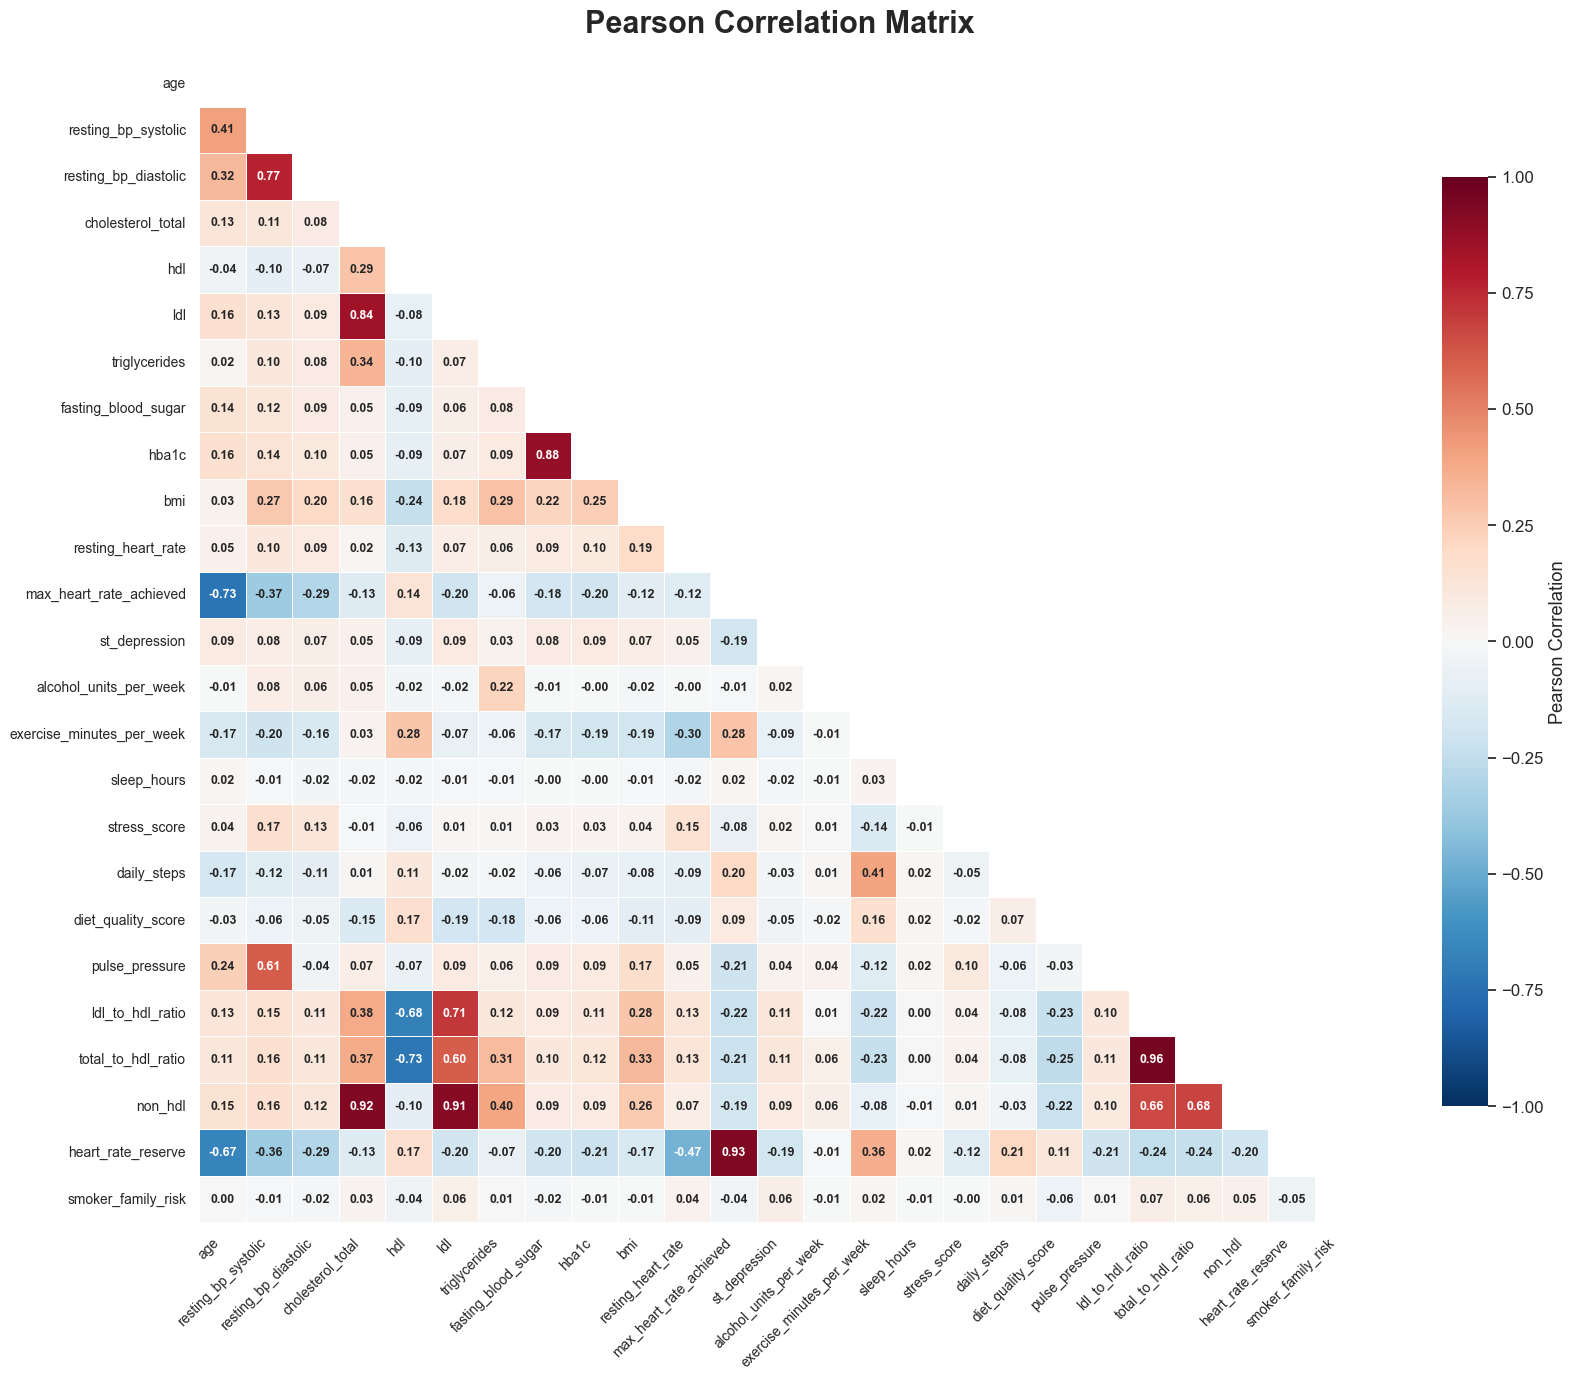

In [43]:

# Style
sns.set_theme(style="white", font_scale=1.1)

# Correlation Matrix
corr_matrix = X_train[numeric_features].corr(method="pearson")

# إظهار نصف المصفوفة فقط
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size":9, "weight":"bold"},
    cbar_kws={
        "shrink":0.8,
        "label":"Pearson Correlation"
    },
    vmin=-1,
    vmax=1
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(
    "Pearson Correlation Matrix",
    fontsize=22,
    fontweight="bold",
    pad=20
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [44]:
corr = corr_matrix.abs()

high_corr = (
    corr.where(~(corr == 1))
        .stack()
        .sort_values(ascending=False)
)

high_corr_df = (
    high_corr[high_corr > 0.80]
    .reset_index()
)

high_corr_df.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr_df

,Feature 1,Feature 2,Correlation
0,ldl_to_hdl_ratio,total_to_hdl_ratio,0.956715
1,total_to_hdl_ratio,ldl_to_hdl_ratio,0.956715
2,max_heart_rate_achieved,heart_rate_reserve,0.933036
3,heart_rate_reserve,max_heart_rate_achieved,0.933036
4,non_hdl,cholesterol_total,0.924927
5,cholesterol_total,non_hdl,0.924927
6,ldl,non_hdl,0.907840
7,non_hdl,ldl,0.907840
8,hba1c,fasting_blood_sugar,0.876964
9,fasting_blood_sugar,hba1c,0.876964


Correlation Analysis: Several engineered features showed high correlations with their source variables (e.g., non_hdl with cholesterol_total, and heart_rate_reserve with max_heart_rate_achieved). These relationships are expected because the engineered features are derived from existing clinical measurements. Since these features carry meaningful medical interpretations and the primary models include tree-based algorithms that are generally robust to multicollinearity, no features were removed at this stage.

In [45]:
def build_pipeline(model):
    """
    Build a complete machine learning pipeline.
    """

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [46]:
baseline_pipeline = build_pipeline(
    LogisticRegression(random_state=42)
)

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['age','sex','resting_bp_systolic',...,'age_group','smoker_numeric', 'smoker_family_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [47]:
baseline_accuracy = baseline_pipeline.score(
    X_test,
    y_test
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.8478


In [48]:
# ==========================================
# Define Candidate Models
# ==========================================
# Class weighting is applied directly here (rather than as a separate
# later step) because the target is moderately imbalanced
# (~70% No Disease / 30% Disease). This makes every model, from the
# baseline run through tuning and final selection, pay more attention
# to the minority (disease) class from the start.

models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),

    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),

    "LightGBM": LGBMClassifier(random_state=42, class_weight="balanced"),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42,
        auto_class_weights="Balanced"
    )
}


## 6. Model Training & Evaluation

We now train four classification models using the shared preprocessing pipeline (`build_pipeline`) and the already-prepared `X_train`, `X_test`, `y_train`, `y_test`.

In [49]:
# ==========================================
# Additional Imports for Modeling
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import RandomizedSearchCV

import joblib


### 6.1 Train All Baseline Models

Each model is trained inside the same `preprocessor` pipeline for a fair, consistent comparison.

In [50]:
# ==========================================
# Helper Function: Compute Evaluation Metrics
# ==========================================

def evaluate_classifier(name, y_true, y_pred, y_proba):
    """
    Compute standard classification metrics for a single model.
    """
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }


In [51]:
# ==========================================
# Train & Evaluate All Baseline Models
# ==========================================

trained_pipelines = {}
model_predictions = {}
baseline_results = []

for name, model in models.items():

    print(f"Training {name} ...")

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    trained_pipelines[name] = pipeline
    model_predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

    metrics = evaluate_classifier(name, y_test, y_pred, y_proba)
    baseline_results.append(metrics)

    print(f"\n{'='*65}")
    print(f"Classification Report - {name}")
    print(f"{'='*65}")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"{'='*65}\n")


Training Logistic Regression ...

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1255
           1       0.73      0.83      0.78       545

    accuracy                           0.85      1800
   macro avg       0.82      0.85      0.83      1800
weighted avg       0.86      0.85      0.86      1800

Confusion Matrix:
[[1086  169]
 [  93  452]]

Training Random Forest ...

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1255
           1       0.80      0.80      0.80       545

    accuracy                           0.88      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.88      0.88      0.88      1800

Confusion Matrix:
[[1147  108]
 [ 107  438]]

Training LightGBM ...
[LightGBM] [Info] Number of positive: 2182, number of negative: 5018
[LightGBM] [Info] A

### 6.2 Compare Baseline Models

All metrics are collected into a single comparison table sorted by ROC-AUC, with the best model highlighted.

In [52]:
# ==========================================
# Baseline Model Comparison Table
# ==========================================

comparison_df = (
    pd.DataFrame(baseline_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

def highlight_best_roc(s):
    is_max = s == s.max()
    return ["background-color: lightgreen; font-weight: bold" if v else "" for v in is_max]

best_baseline_model = comparison_df.iloc[0]["Model"]
print(f"Best baseline model (by ROC-AUC): {best_baseline_model}")

comparison_df.style.apply(highlight_best_roc, subset=["ROC-AUC"])


Best baseline model (by ROC-AUC): CatBoost


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.879444,0.788732,0.822018,0.805031,0.946739
1,LightGBM,0.880000,0.793226,0.816514,0.804702,0.943865
2,Random Forest,0.880556,0.802198,0.803670,0.802933,0.941217
3,Logistic Regression,0.854444,0.727858,0.829358,0.775300,0.934328


### 6.3 Model Selection via Cross-Validation 

To avoid using the Test Set for model-selection decisions, the top 2 models for
tuning are chosen using **Cross-Validation ROC-AUC** computed only on
`X_train`/`y_train`. The Test Set is reserved exclusively for the final,
one-time evaluation after tuning.

In [53]:
# ==========================================
# Cross-Validation Based Model Comparison
# (Test Set is NOT used here - selection is based on Train only)
# ==========================================

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    print(f"Cross-validating {name} ...")

    pipeline = build_pipeline(model)

    scores = cross_val_score(
        pipeline,
        X_train, y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

cv_comparison_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV ROC-AUC Mean", ascending=False)
    .reset_index(drop=True)
)

cv_comparison_df

Cross-validating Logistic Regression ...
Cross-validating Random Forest ...
Cross-validating LightGBM ...
Cross-validating CatBoost ...


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,CatBoost,0.951842,0.005440
1,LightGBM,0.947800,0.006815
2,Logistic Regression,0.940091,0.006124
3,Random Forest,0.937084,0.006075


## 7. Hyperparameter Tuning

We tune only the **top 2 models** (by ROC-AUC) using `RandomizedSearchCV` with 5-fold cross-validation, `scoring="roc_auc"`, and 25 iterations.

In [54]:
# ==========================================
# Select Top 2 Models for Tuning
# (Selected using Cross-Validation results, NOT the Test Set,
# to keep the Test Set fully unseen until final evaluation)
# ==========================================

top_2_models = cv_comparison_df.head(2)["Model"].tolist()
print("Top 2 models selected for hyperparameter tuning (by CV ROC-AUC):", top_2_models)

Top 2 models selected for hyperparameter tuning (by CV ROC-AUC): ['CatBoost', 'LightGBM']


In [55]:
# ==========================================
# Model Variants Used ONLY for Tuning
# ==========================================
# Setting n_jobs / thread_count = 1 here avoids the model competing
# for CPU cores with RandomizedSearchCV's own n_jobs=-1 parallelism,
# which otherwise causes oversubscription and much slower search.
# Class weighting is kept consistent with the baseline models above.

tuning_models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=1, class_weight="balanced"),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=1, class_weight="balanced"),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=1, auto_class_weights="Balanced"),
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
}


In [56]:
# ==========================================
# Run RandomizedSearchCV for Top 2 Models
# ==========================================

from sklearn.model_selection import train_test_split as _tts
from sklearn.base import clone

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [  100, 150,  200],
        "model__max_depth": [None, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },
    "LightGBM": {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [-1, 5, 7, 10],
        "model__num_leaves": [15, 31, 63],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0]
    },
    "CatBoost": {
        "model__iterations": [100, 150, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__depth": [4, 6, 8],
        "model__l2_leaf_reg": [1, 3, 5, 7]
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    }
}

X_train_search, _, y_train_search, _ = _tts(
    X_train, y_train,
    train_size=0.5,
    stratify=y_train,
    random_state=42
)

tuned_pipelines = {}
tuning_best_params = {}

for name in top_2_models:

    print(f"Tuning {name} ...")

    base_pipeline = build_pipeline(tuning_models[name])

    search = RandomizedSearchCV(
        estimator=base_pipeline,
        param_distributions=param_distributions[name],
        n_iter=10,
        scoring="roc_auc",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    # Search on the smaller subsample to find the best parameters fast
    search.fit(X_train_search, y_train_search)

    print(f"Best CV ROC-AUC (on subsample): {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

    # Refit the best configuration on the FULL training set
    final_pipeline = clone(build_pipeline(models[name]))
    final_pipeline.set_params(**search.best_params_)
    final_pipeline.fit(X_train, y_train)

    tuned_pipelines[name] = final_pipeline
    tuning_best_params[name] = search.best_params_

    print(f"Refit on full training data complete.\n")


Tuning CatBoost ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV ROC-AUC (on subsample): 0.9497
Best Params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 7, 'model__iterations': 200, 'model__depth': 4}
Refit on full training data complete.

Tuning LightGBM ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 1091, number of negative: 2509
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3580
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best CV ROC-AUC (on subsample): 0.9453
Best Params: {'model__subsample': 0.7, 'model__num_leaves': 15, 'model__n_estimators': 200, 'model__max_depth': 7, 'mo

## 8. Evaluate Tuned Models

In [57]:
# ==========================================
# Evaluate Tuned Models on Test Set
# ==========================================

tuned_results = []

for name, pipeline in tuned_pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    model_predictions[name]["y_pred_tuned"] = y_pred
    model_predictions[name]["y_proba_tuned"] = y_proba

    metrics = evaluate_classifier(name, y_test, y_pred, y_proba)
    tuned_results.append(metrics)

tuned_comparison_df = (
    pd.DataFrame(tuned_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

tuned_comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.870000,0.757025,0.840367,0.796522,0.947258
1,LightGBM,0.876667,0.772344,0.840367,0.804921,0.944189


In [58]:
# ==========================================
# Before vs After Tuning Comparison
# ==========================================

metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

before_after_rows = []

for name in top_2_models:
    before = comparison_df.loc[comparison_df["Model"] == name].iloc[0]
    after = tuned_comparison_df.loc[tuned_comparison_df["Model"] == name].iloc[0]

    for metric in metric_cols:
        before_after_rows.append({
            "Model": name,
            "Metric": metric,
            "Before Tuning": round(before[metric], 4),
            "After Tuning": round(after[metric], 4),
            "Improved": after[metric] > before[metric]
        })

before_after_df = pd.DataFrame(before_after_rows)
before_after_df


,Model,Metric,Before Tuning,After Tuning,Improved
0,CatBoost,Accuracy,0.8794,0.8700,False
1,CatBoost,Precision,0.7887,0.7570,False
2,CatBoost,Recall,0.8220,0.8404,True
3,CatBoost,F1-Score,0.8050,0.7965,False
4,CatBoost,ROC-AUC,0.9467,0.9473,True
5,LightGBM,Accuracy,0.8800,0.8767,False
6,LightGBM,Precision,0.7932,0.7723,False
7,LightGBM,Recall,0.8165,0.8404,True
8,LightGBM,F1-Score,0.8047,0.8049,True
9,LightGBM,ROC-AUC,0.9439,0.9442,True


## 9. Visualizations

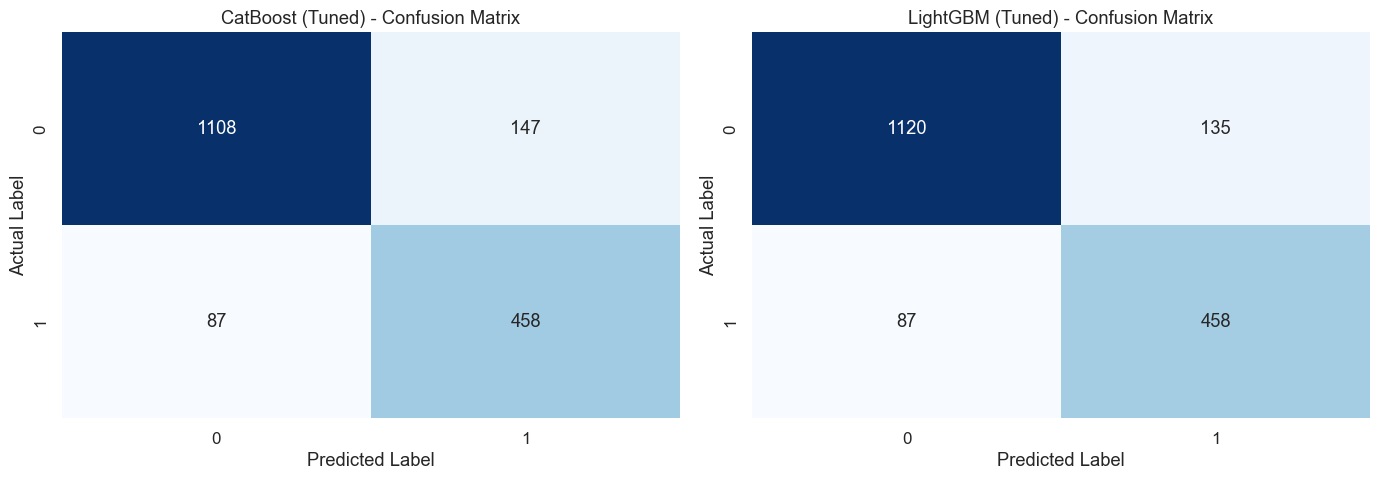

In [59]:
# ==========================================
# Confusion Matrix - Final Tuned Models
# ==========================================

fig, axes = plt.subplots(1, len(top_2_models), figsize=(7 * len(top_2_models), 5))

if len(top_2_models) == 1:
    axes = [axes]

for ax, name in zip(axes, top_2_models):
    y_pred = model_predictions[name]["y_pred_tuned"]
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name} (Tuned) - Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()


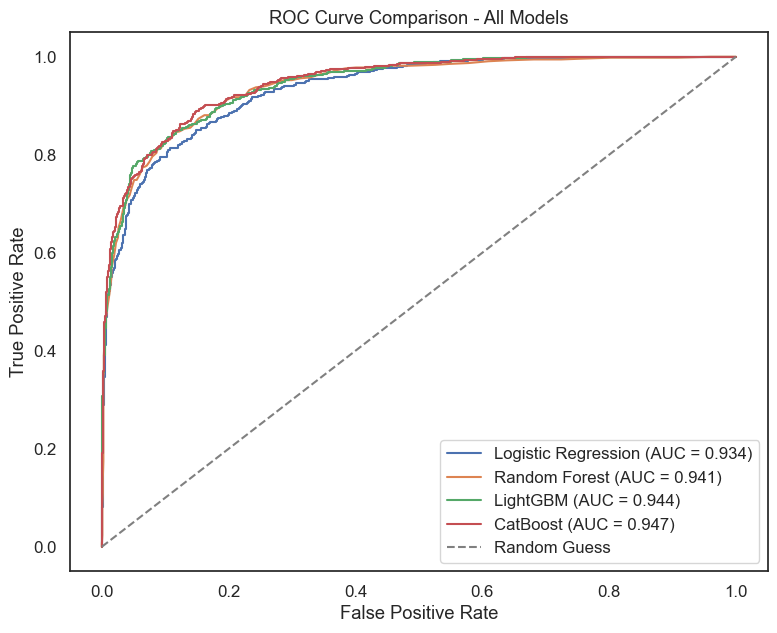

In [60]:
# ==========================================
# ROC Curve Comparison - All Baseline Models
# ==========================================

plt.figure(figsize=(9, 7))

for name in models.keys():
    y_proba = model_predictions[name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend(loc="lower right")
plt.show()


In [61]:
# ==========================================
# Final Metrics Table (Best of Baseline / Tuned)
# ==========================================
# For the two tuned models, the tuned metrics replace the baseline
# metrics. Non-tuned models keep their baseline metrics.

final_comparison_df = comparison_df.copy()

for name in top_2_models:
    tuned_row = tuned_comparison_df.loc[tuned_comparison_df["Model"] == name].iloc[0]
    final_comparison_df.loc[final_comparison_df["Model"] == name, metric_cols] = tuned_row[metric_cols].values

final_comparison_df = final_comparison_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
final_comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.870000,0.757025,0.840367,0.796522,0.947258
1,LightGBM,0.876667,0.772344,0.840367,0.804921,0.944189
2,Random Forest,0.880556,0.802198,0.803670,0.802933,0.941217
3,Logistic Regression,0.854444,0.727858,0.829358,0.775300,0.934328


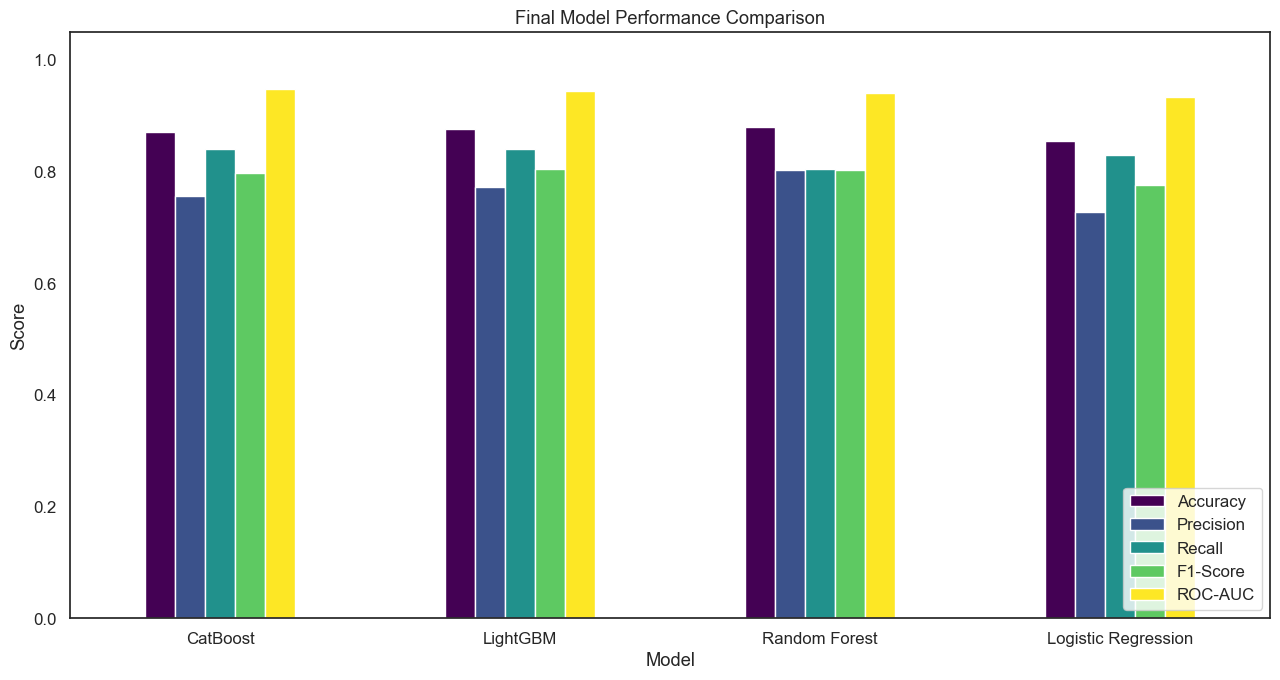

In [62]:
# ==========================================
# Bar Chart - Final Metric Comparison
# ==========================================

plot_df = final_comparison_df.set_index("Model")[metric_cols]

plot_df.plot(kind="bar", figsize=(13, 7), colormap="viridis")
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


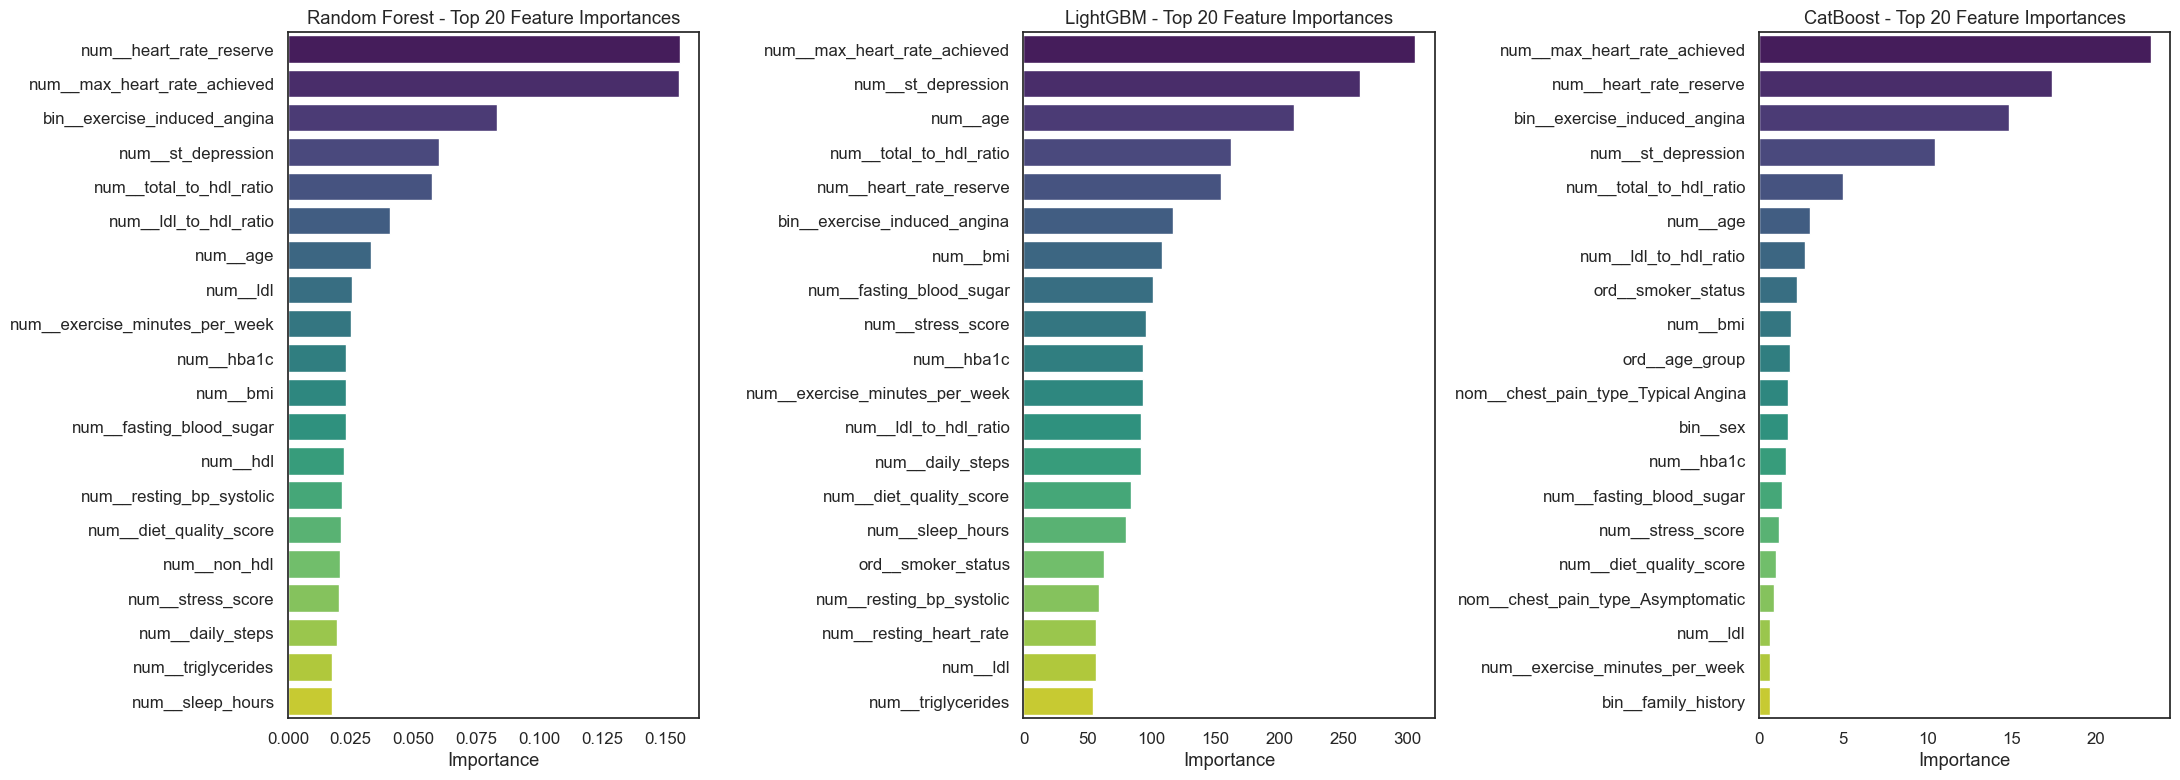

In [63]:
# ==========================================
# Feature Importance - Tree-Based Models (Top 20)
# ==========================================

final_pipelines = {
    name: (tuned_pipelines[name] if name in tuned_pipelines else trained_pipelines[name])
    for name in models.keys()
}

tree_based_models = ["Random Forest", "LightGBM", "CatBoost"]

fig, axes = plt.subplots(1, len(tree_based_models), figsize=(22, 8))

for ax, name in zip(axes, tree_based_models):
    pipeline = final_pipelines[name]
    fitted_model = pipeline.named_steps["model"]
    feat_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    importances = fitted_model.feature_importances_

    importance_df = (
        pd.DataFrame({"Feature": feat_names, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    sns.barplot(data=importance_df, y="Feature", x="Importance", ax=ax, palette="viridis")
    ax.set_title(f"{name} - Top 20 Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## 10. Final Model Selection

In [64]:
# ==========================================
# Automatically Select the Best Final Model
# ==========================================
# Class weighting is already built into every model (see Section 6),
# so no separate threshold search is needed here - the standard 0.5
# decision threshold is used.

best_model_name = final_comparison_df.iloc[0]["Model"]
best_pipeline = final_pipelines[best_model_name]
best_metrics = final_comparison_df.iloc[0]

best_params = tuning_best_params.get(
    best_model_name,
    "Default parameters (model was not tuned; baseline was already the best)"
)

print("="*65)
print("FINAL MODEL")
print("="*65)
print(f"Model               : {best_model_name}")
print(f"Class Weighting     : Enabled (balanced) - built in from the start")
print(f"Decision Threshold  : 0.5 (default)")
print(f"Best Parameters     : {best_params}")
print("-"*65)
print("Final Test Metrics:")
for metric in metric_cols:
    print(f"  {metric:<10}: {best_metrics[metric]:.4f}")
print("="*65)

print(
    f"\n'{best_model_name}' was selected as the final model because it achieved "
    f"the highest ROC-AUC ({best_metrics['ROC-AUC']:.4f}) on the held-out test set. "
    "Class weighting was built into every model from the start to counter the "
    "70/30 class imbalance, so no additional threshold adjustment was needed."
)


FINAL MODEL
Model               : CatBoost
Class Weighting     : Enabled (balanced) - built in from the start
Decision Threshold  : 0.5 (default)
Best Parameters     : {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 7, 'model__iterations': 200, 'model__depth': 4}
-----------------------------------------------------------------
Final Test Metrics:
  Accuracy  : 0.8700
  Precision : 0.7570
  Recall    : 0.8404
  F1-Score  : 0.7965
  ROC-AUC   : 0.9473

'CatBoost' was selected as the final model because it achieved the highest ROC-AUC (0.9473) on the held-out test set. Class weighting was built into every model from the start to counter the 70/30 class imbalance, so no additional threshold adjustment was needed.


## 11. Save Final Model

In [65]:
# ==========================================
# Save Only the Final Best Model
# ==========================================
# The saved pipeline already includes the fitted preprocessor
# (ColumnTransformer) and the class-weighted model, so no separate
# preprocessing object or threshold value is required.

joblib.dump(best_pipeline, "best_model.joblib")

print(f"Saved final model ('{best_model_name}') to best_model.joblib")


Saved final model ('CatBoost') to best_model.joblib
